In [2]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
from sklearn.metrics import mean_squared_error, accuracy_score
from scipy import stats
import numpy as np
import torch

from src.data import *
from src.models import *
from src.visualization import *
from src.train_utils import *

In [3]:
NUM_FOLDS = 5
DATA_SPLIT_SEED = 42
SEED = 42
BATCH_SIZE = 128
EPOCHS = 35
PATIENCE = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.1
TEST_SIZE = 0.1
DATA_PATH = "dataset.tsv"
MODEL_CLASS = DeepSTARRRDSEB
USE_RC_TTA_TEST_EVALUATION = True
NORMALIZED_PREDICTION_USED = True
CHECKPOINT_DIR = Path(f"models/{MODEL_CLASS.__name__}")
CHECKPOINT_DIR.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() 
            else 'mps' if torch.backends.mps.is_available() 
            else 'cpu')
print(f'DEVICE: {DEVICE}')

DEVICE: mps


In [22]:
df = load_data(DATA_PATH)

cv_loaders = make_cross_val_loaders(
    df=df,
    n_splits=5,
    seed=DATA_SPLIT_SEED,
    test_size=TEST_SIZE,
    batch_size=BATCH_SIZE,
    normalize=NORMALIZED_PREDICTION_USED,
)

print(f"number of folds: {len(cv_loaders)}")
print(f"mean: {cv_loaders[0][3]} | std: {cv_loaders[0][4]}")
print(f"mean: {cv_loaders[1][3]} | std: {cv_loaders[1][4]}")
print(f"mean: {cv_loaders[2][3]} | std: {cv_loaders[2][4]}")
print(f"mean: {cv_loaders[3][3]} | std: {cv_loaders[3][4]}")
print(f"mean: {cv_loaders[4][3]} | std: {cv_loaders[4][4]}")

number of folds: 5
mean: -0.223523033327482 | std: 0.7816540023491542
mean: -0.22291308272939292 | std: 0.7829750402797601
mean: -0.22355943126535932 | std: 0.7871591306205017
mean: -0.22028105722453484 | std: 0.7864000032524769
mean: -0.2223364260996038 | std: 0.7837068963255216


In [ ]:
for fold_idx, (train_loader, val_loader, test_loader, mean, std) in enumerate(cv_loaders, start=1):
    print(f"=== FOLD {fold_idx}/5 ===")

    model, optimizer, scheduler = build_model(
        seed=SEED,
        model_class=MODEL_CLASS,
        device=DEVICE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    train(
        seed=SEED,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        device=DEVICE,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        patience=PATIENCE,
        ckpt_path=CHECKPOINT_DIR / f"model_fold{fold_idx}_seed{SEED}.pt",
        meta_path=CHECKPOINT_DIR / f"model_fold{fold_idx}_seed{SEED}_meta.json",
        mean=mean,
        std=std,
    )

In [16]:
all_preds = []
for fold_idx, (_, _, test_loader, mean, std) in enumerate(cv_loaders, start=1):
    model = load_model(
        model_class=MODEL_CLASS,
        device=DEVICE,
        ckpt_path=CHECKPOINT_DIR / f"model_fold{fold_idx}_seed{SEED}.pt",
    )

    metrics = evaluate_model(
        model=model, 
        loader=test_loader, 
        device=DEVICE,
        normalized_prediction_used=NORMALIZED_PREDICTION_USED,
        mean=mean,
        std=std,
        use_rc_tta=True,
    ) 

    all_preds.append(metrics)

/Users/domi/Documents/studia/08_sem/deep_learning_in_life_science/dr448657/src/visualization.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state = torch.load(ck


===== Test Ensemble =====
Loss:     0.2317
MSE:      0.2954
Pearson:  0.7236
Spearman: 0.7138
Accuracy: 0.8117


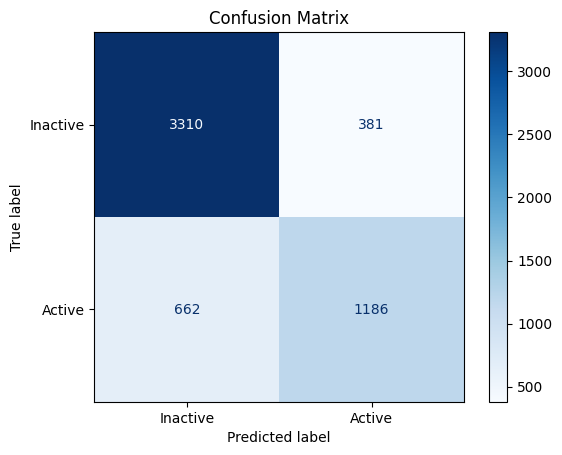

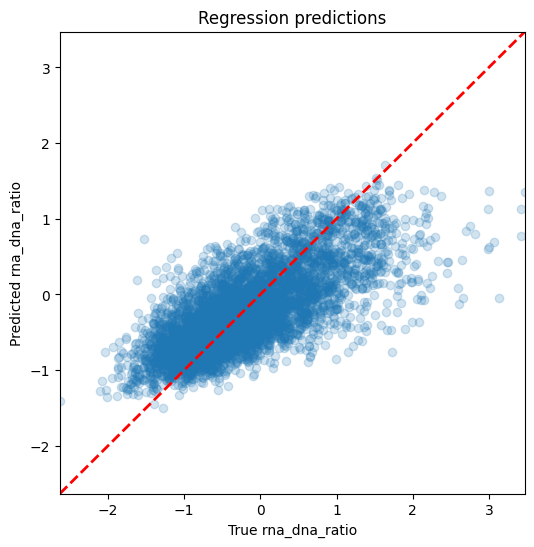

In [20]:
y_pred_ratio = np.mean([pred["y_pred_rna_dna_ratio"] for pred in all_preds], axis=0)
y_pred_active = (y_pred_ratio > 0).astype(int)
y_true_ratio = all_preds[0]["y_true_rna_dna_ratio"]
y_true_active = all_preds[0]["y_true_active"]

metrics = {
    "y_true_rna_dna_ratio": all_preds[0]["y_true_rna_dna_ratio"],
    "y_pred_rna_dna_ratio": y_pred_ratio,
    "y_true_active": all_preds[0]["y_true_active"],
    "y_pred_active": y_pred_active,
}

printed_metrics = {
    "loss": np.mean([pred["loss"] for pred in all_preds]),
    "mse" : mean_squared_error(y_true_ratio, y_pred_ratio),
    "pearson": stats.pearsonr(y_true_ratio, y_pred_ratio)[0],
    "spearman": stats.spearmanr(y_true_ratio, y_pred_ratio)[0],
    "acc": accuracy_score(y_true_active, y_pred_active),
}

print_metrics(printed_metrics, set_name="Test Ensemble")
plot_confusion_matrix(metrics["y_true_active"], metrics["y_pred_active"])
plot_regression(metrics["y_true_rna_dna_ratio"], metrics["y_pred_rna_dna_ratio"])